<a href="https://colab.research.google.com/github/eom-hope/ABCD-A/blob/20250529/yolov8_train_segment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. 초기 환경 설정

In [ ]:
# YOLOv8 설치
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 100.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [ ]:
# 필요한 라이브러리 임포트
import os
from ultralytics import YOLO
import shutil
from google.colab import drive
from google.colab import files

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# 파일 선택기를 통한 업로드
uploaded = files.upload()

Saving Test.v1i.yolov8.zip to Test.v1i.yolov8.zip


In [ ]:
# 코랩 셀에서 ! 를 앞에 붙여서 실행
!mkdir -p /content/dataset
!unzip /content/Test.v1i.yolov8.zip -d /content/dataset

Archive:  /content/Test.v1i.yolov8.zip
replace /content/dataset/README.dataset.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/dataset/README.roboflow.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace /content/dataset/README.roboflow.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/dataset/README.roboflow.txt  
  inflating: /content/dataset/data.yaml  
 extracting: /content/dataset/train/images/151-_jpg.rf.405ad85fe14d7f381b14f185aa8eeb20.jpg  
 extracting: /content/dataset/train/images/152-_jpg.rf.b66c958a5f586f0427d9ac2e9962073d.jpg  
 extracting: /content/dataset/train/images/153-_jpg.rf.c9ce8f6d8dbb2e34b85f103484e1996d.jpg  
 extracting: /content/dataset/train/images/154-_jpg.rf.7c6199789a00623779b4876b0d051ad8.jpg  
 extracting: /content/dataset/train/images/155-_jpg.rf.b8e4292d49f46ea193b1d13778439c10.jpg  
 extracting: /content/dataset/train/images/156-_jpg.rf.7bfcdedae99bff5ee325ddb4731748a5.jpg  
 extracting: /con

다음 폴더 구조를 수정합니다.


content/

├── dataset
│   ├──train
│   │   ├──images
│   │   ├──labels
│   ├──valid
│   │   ├──images
│   ├──test
│   │   ├──images
└── data.yaml





In [ ]:
#test/images 폴더 생성
!mkdir -p /content/dataset/test/images
!cp /content/dataset/train/images/* /content/dataset/test/images/

In [ ]:
#valid/images 폴더 생성
!mkdir -p /content/dataset/valid/images
!cp /content/dataset/train/images/* /content/dataset/valid/images/

In [ ]:
#valid/labels 폴더 생성
!mkdir -p /content/dataset/valid/labels
!cp /content/dataset/train/labels/* /content/dataset/valid/labels/

#data.yaml 파일 수정

train: /content/dataset/train/images
val: /content/dataset/valid/images
test: /content/dataset/test/images

In [ ]:
# 학습 시작
from ultralytics import YOLO

# Segmentation 모델로 학습
model = YOLO('yolov8l-seg.pt')  # segmentation 모델 사용

results = model.train(
    data='/content/dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='yolov8_seg_custom',
    project='/content/runs/train',
    patience=10,
    save=True,
    device=0
)

Ultralytics 8.3.145 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_seg_custom2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plots=True, pose=12.0,

train: Scanning /content/dataset/train/labels.cache... 20 images, 0 backgrounds, 4 corrupt: 100%|██████████| 20/20 [00:00<?, ?it/s]

train: /content/dataset/train/images/img_0000_2025-05-04_17-05-09_jpg.rf.69a8081072e33f5aefeb01858c69c1f4.jpg: ignoring corrupt image/label: Label class 5 exceeds dataset class count 5. Possible class labels are 0-4
train: /content/dataset/train/images/img_0001_2025-05-04_17-05-11_jpg.rf.a051e698af94a5c54437366fb245d60f.jpg: ignoring corrupt image/label: Label class 5 exceeds dataset class count 5. Possible class labels are 0-4
train: /content/dataset/train/images/img_0095_2025-05-04_17-07-17_jpg.rf.11b1b90f2bc2e553a27e50b2ca34856d.jpg: ignoring corrupt image/label: Label class 5 exceeds dataset class count 5. Possible class labels are 0-4
train: /content/dataset/train/images/img_0205_2025-05-04_17-09-49_jpg.rf.ac67c3756cd132a08d9f8c7ba14050df.jpg: ignoring corrupt image/label: Label class 5 exceeds dataset class count 5. Possible class labels are 0-4
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_ou

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 359.3±197.1 MB/s, size: 21.3 KB)


val: Scanning /content/dataset/valid/labels.cache... 20 images, 0 backgrounds, 4 corrupt: 100%|██████████| 20/20 [00:00<?, ?it/s]

...


41 epochs completed in 0.054 hours.
Optimizer stripped from /content/runs/train/yolov8_seg_custom2/weights/last.pt, 92.3MB
Optimizer stripped from /content/runs/train/yolov8_seg_custom2/weights/best.pt, 92.3MB

Validating /content/runs/train/yolov8_seg_custom2/weights/best.pt...
Ultralytics 8.3.145 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8l-seg summary (fused): 125 layers, 45,915,743 parameters, 0 gradients, 220.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):   0%|          | 0/1 [00:00<?, ?it/s]

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  1.76it/s]


                   all         16        119      0.714      0.885      0.888      0.733      0.707      0.876      0.873      0.581
           dotted-line         15         59      0.956      0.742      0.948      0.746      0.911      0.698      0.894      0.493
             left_lane         16         19      0.523      0.895      0.905      0.747      0.523      0.895      0.886       0.63
             left_line         15         15      0.409      0.867      0.676       0.56      0.411      0.867      0.676      0.422
            right_lane         13         13      0.826          1      0.995      0.771      0.835          1      0.995      0.647
            right_line         13         13      0.854      0.923      0.915      0.841      0.855      0.923      0.915      0.714
Speed: 0.2ms preprocess, 20.0ms inference, 0.0ms loss, 2.7ms postprocess per image
Results saved to /content/runs/train/yolov8_seg_custom2


In [ ]:
# 학습된 모델 로드(폴더에 맞도록)
model = YOLO('/content/runs/train/yolov8_seg_custom2/weights/best.pt')

# 테스트 실행
results = model.predict(
    source='/content/dataset/test/images',  # 테스트 이미지 경로
    save=True,                              # 결과 저장
    save_txt=True,                          # 텍스트 결과도 저장
    conf=0.5,                               # 신뢰도 임계값
    project='/content/runs/detect',         # 저장 프로젝트 경로
    name='test_results'                     # 폴더 이름 지정
)


image 1/20 /content/dataset/test/images/151-_jpg.rf.405ad85fe14d7f381b14f185aa8eeb20.jpg: 640x640 5 dotted-lines, 3 left_lanes, 2 left_lines, 1 right_lane, 2 right_lines, 63.1ms
image 2/20 /content/dataset/test/images/152-_jpg.rf.b66c958a5f586f0427d9ac2e9962073d.jpg: 640x640 3 dotted-lines, 1 left_lane, 1 left_line, 1 right_lane, 2 right_lines, 56.1ms
image 3/20 /content/dataset/test/images/153-_jpg.rf.c9ce8f6d8dbb2e34b85f103484e1996d.jpg: 640x640 4 dotted-lines, 2 left_lanes, 1 left_line, 1 right_lane, 2 right_lines, 56.0ms
image 4/20 /content/dataset/test/images/154-_jpg.rf.7c6199789a00623779b4876b0d051ad8.jpg: 640x640 3 dotted-lines, 1 left_lane, 1 left_line, 1 right_lane, 1 right_line, 41.4ms
image 5/20 /content/dataset/test/images/155-_jpg.rf.b8e4292d49f46ea193b1d13778439c10.jpg: 640x640 4 dotted-lines, 2 left_lanes, 1 left_line, 2 right_lanes, 2 right_lines, 41.8ms
image 6/20 /content/dataset/test/images/156-_jpg.rf.7bfcdedae99bff5ee325ddb4731748a5.jpg: 640x640 4 dotted-lines, 2

In [ ]:
import cv2

def draw_enhanced_results(image_path, results):
    """세그멘테이션 마스크를 이미지 위에 시각화"""
    # 이미지 로드
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 클래스 색상 정의
    class_names = ['dotted-line', 'left_lane', 'left_line', 'right_lane', 'right_line']
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255)]

    for result in results:
        masks = result.masks  # 마스크 객체

        if masks is not None and masks.data is not None:
            mask_data = masks.data.cpu().numpy()  # (N, H, W)
            cls_list = result.boxes.cls.cpu().numpy().astype(int)  # 클래스 인덱스 리스트
            conf_list = result.boxes.conf.cpu().numpy()  # 신뢰도

            for i in range(len(mask_data)):
                mask = mask_data[i]
                cls_id = cls_list[i]
                conf = conf_list[i]

                # 마스크 색상 및 클래스 이름
                color = colors[cls_id % len(colors)]
                class_name = class_names[cls_id] if cls_id < len(class_names) else f'class_{cls_id}'
                label = f'{class_name}: {conf:.2f}'

                # 마스크를 컬러로 적용
                colored_mask = np.zeros_like(img_rgb, dtype=np.uint8)
                for c in range(3):
                    colored_mask[:, :, c] = mask * color[c]

                # 반투명하게 overlay
                img_rgb = cv2.addWeighted(img_rgb, 1.0, colored_mask, 0.4, 0)

                # 마스크 경계 추출하여 텍스트 위치 추정
                contours, _ = cv2.findContours((mask * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                if contours:
                    x, y, w, h = cv2.boundingRect(contours[0])
                    # 라벨 텍스트
                    (text_width, text_height), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
                    cv2.rectangle(img_rgb, (x, y - text_height - 10), (x + text_width, y), color, -1)
                    cv2.putText(img_rgb, label, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    return img_rgb


Results saved to /content/runs/detect/test_results
20 labels saved to /content/runs/detect/test_results/labels


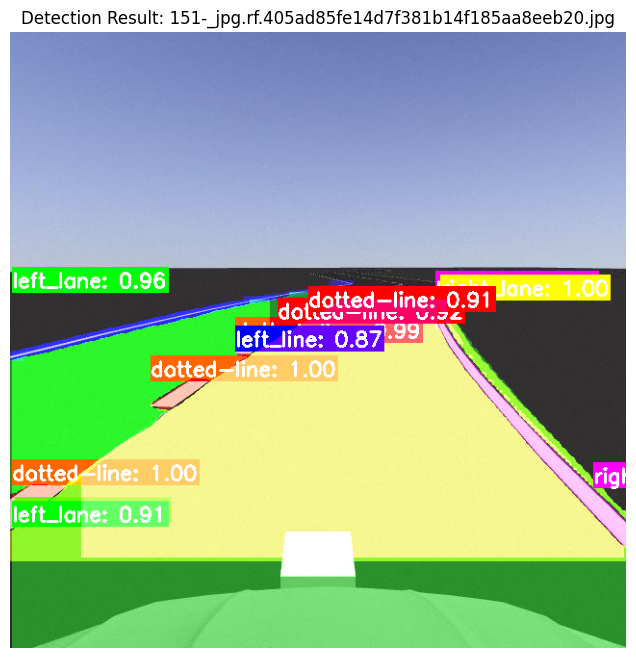

Results saved to /content/runs/detect/test_results
20 labels saved to /content/runs/detect/test_results/labels


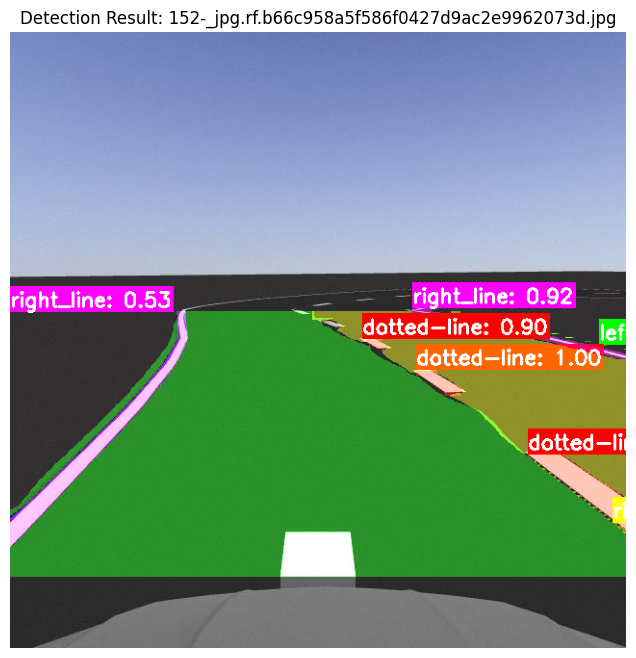

Results saved to /content/runs/detect/test_results
20 labels saved to /content/runs/detect/test_results/labels


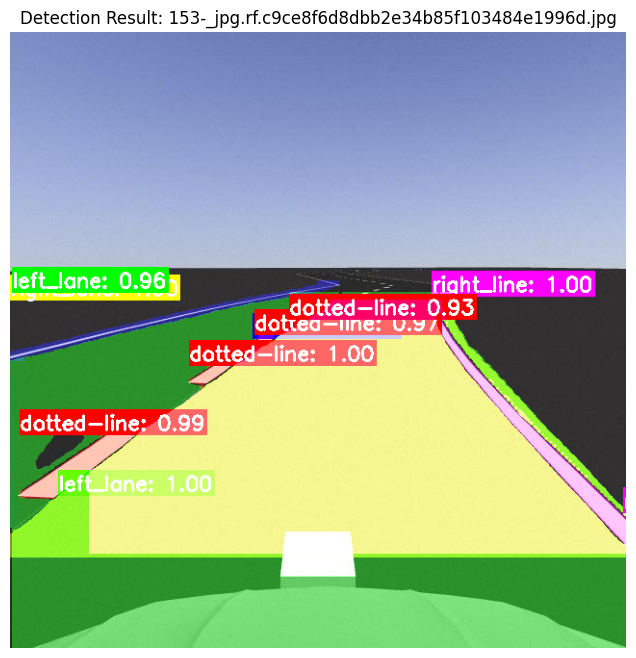

Results saved to /content/runs/detect/test_results
20 labels saved to /content/runs/detect/test_results/labels


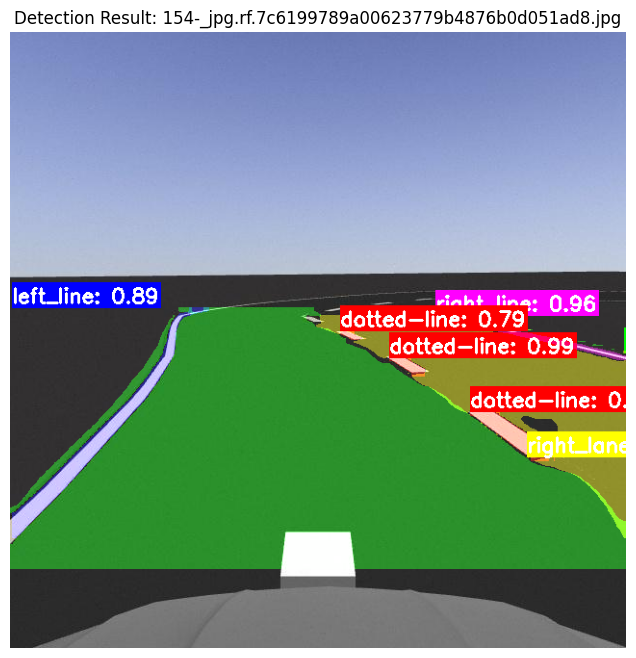

Results saved to /content/runs/detect/test_results
20 labels saved to /content/runs/detect/test_results/labels


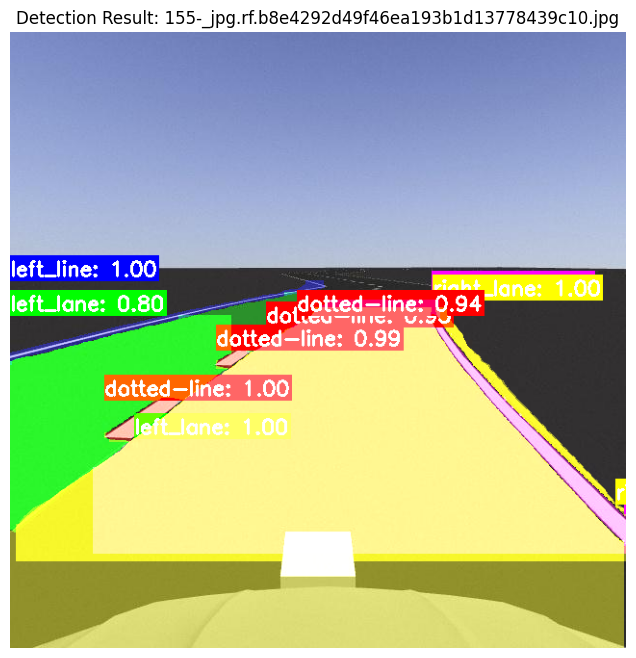

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

image_dir = '/content/dataset/test/images/'
test_images = sorted([img for img in os.listdir(image_dir) if img.lower().endswith(('.png', '.jpg', '.jpeg'))])


for i, img_name in enumerate(test_images[:5]):  # 처음 5개만
    img_path = f'/content/dataset/test/images/{img_name}'

    # 예측 실행
    result = model.predict(img_path, conf=0.5, verbose=False)

    # 향상된 시각화
    enhanced_img = draw_enhanced_results(img_path, result)

    # 결과 표시
    plt.figure(figsize=(12, 8))
    plt.imshow(enhanced_img)
    plt.title(f'Detection Result: {img_name}')
    plt.axis('off')
    plt.show()


In [ ]:
import shutil
from google.colab import files

# 1. zip 파일로 압축 (기존 zip 파일이 있다면 덮어씌움)
shutil.make_archive('/content/runs_backup', 'zip', '/content/runs')

# 2. 다운로드 링크 제공
files.download('/content/runs_backup.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#동영상으로 만들기

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# YOLO 예측 + 시각화 함수 (콜라보용)
image_dir = '/content/dataset/test/images/'
test_images = sorted([img for img in os.listdir(image_dir) if img.lower().endswith(('.png', '.jpg', '.jpeg'))])

frames = []

for i, img_name in enumerate(test_images[:5]):  # 처음 5개만
    img_path = os.path.join(image_dir, img_name)

    # 예측 실행
    result = model.predict(img_path, conf=0.5, verbose=False)

    # 향상된 시각화
    enhanced_img = draw_enhanced_results(img_path, result)

    # RGB -> BGR (OpenCV용)
    bgr_img = cv2.cvtColor(np.array(enhanced_img), cv2.COLOR_RGB2BGR)

    # 모든 프레임 사이즈를 동일하게 유지
    bgr_img = cv2.resize(bgr_img, (1280, 720))

    frames.append(bgr_img)

# 🔄 동영상 생성
video_path = "/content/detection_results.mp4"
fps = 2  # 0.5초 간격 = 2프레임/초
height, width, _ = frames[0].shape
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # 코덱 설정

out = cv2.VideoWriter(video_path, fourcc, fps, (width, height))

for frame in frames:
    out.write(frame)

out.release()
print(f"✅ 영상 저장 완료: {video_path}")

# Colab에서 다운로드 링크 제공
from google.colab import files
files.download(video_path)


Results saved to /content/runs/detect/test_results
20 labels saved to /content/runs/detect/test_results/labels
Results saved to /content/runs/detect/test_results
20 labels saved to /content/runs/detect/test_results/labels
Results saved to /content/runs/detect/test_results
20 labels saved to /content/runs/detect/test_results/labels
Results saved to /content/runs/detect/test_results
20 labels saved to /content/runs/detect/test_results/labels
Results saved to /content/runs/detect/test_results
20 labels saved to /content/runs/detect/test_results/labels
✅ 영상 저장 완료: /content/detection_results.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>